# IP102 Baseline CNN - Rice Pest Classification

This notebook trains the team's scratch-built baseline CNN on ten rice-pest classes from IP102. It follows the simple flow of the Day 3 PyTorch CNN notebook while adding validation, macro F1, early stopping, learning curves, a confusion matrix, and sample predictions.

**Model constraint:** only primitive PyTorch layers, random initialization, no pretrained weights, and no imported prebuilt CNN architecture.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import copy
import csv
import random
import re
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {DEVICE}')

PyTorch version: 2.13.0+cpu
Device: cpu


## 2. Paths, selected classes, and training configuration

The notebook preserves the official IP102 train, validation, and test splits. Original IP102 labels are remapped to contiguous project labels `0-9`.

In [3]:
# Resolve the repository root when Jupyter starts in the root or notebooks folder.
PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent

DATA_ROOT = PROJECT_DIR / 'IP102_v1.1' / 'Classification' / 'ip102_v1.1'
IMAGE_DIR = DATA_ROOT / 'images'
CLASSES_FILE = PROJECT_DIR / 'IP102_v1.1' / 'Classification' / 'classes.txt'
RUN_DIR = PROJECT_DIR / 'runs' / 'justin_baseline_notebook'
RUN_DIR.mkdir(parents=True, exist_ok=True)

assert (PROJECT_DIR / 'configs' / '_base.yaml').exists(), (
    f'Repository root not found from: {Path.cwd()}'
)
assert DATA_ROOT.exists(), f'Dataset folder not found: {DATA_ROOT}'
assert IMAGE_DIR.exists(), f'Image folder not found: {IMAGE_DIR}'
assert CLASSES_FILE.exists(), f'Class file not found: {CLASSES_FILE}'

SELECTED_ORIGINAL_IDS = [0, 1, 3, 4, 5, 7, 8, 9, 10, 11]
ORIGINAL_TO_PROJECT = {
    original_id: project_id
    for project_id, original_id in enumerate(SELECTED_ORIGINAL_IDS)
}

class_lines = CLASSES_FILE.read_text(encoding='utf-8').splitlines()
all_class_names = [re.sub(r'^\s*\d+\s+', '', line).strip() for line in class_lines]
CLASS_NAMES = [all_class_names[class_id] for class_id in SELECTED_ORIGINAL_IDS]
NUM_CLASSES = len(CLASS_NAMES)

IMAGE_SIZE = 160
BATCH_SIZE = 32
MAX_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 10
NUM_WORKERS = 0  # Safest setting for Jupyter on Windows.

# Change this to True for a quick 3-epoch pipeline check.
QUICK_RUN = False
if QUICK_RUN:
    MAX_EPOCHS = 3

print(f'Project directory: {PROJECT_DIR}')
print(f'Dataset directory: {DATA_ROOT}')
print(f'Classes ({NUM_CLASSES}):')
for project_id, (original_id, name) in enumerate(zip(SELECTED_ORIGINAL_IDS, CLASS_NAMES)):
    print(f'  project {project_id} <- IP102 {original_id}: {name}')

Project directory: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI
Dataset directory: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI\IP102_v1.1\Classification\ip102_v1.1
Classes (10):
  project 0 <- IP102 0: rice leaf roller
  project 1 <- IP102 1: rice leaf caterpillar
  project 2 <- IP102 3: asiatic rice borer
  project 3 <- IP102 4: yellow rice borer
  project 4 <- IP102 5: rice gall midge
  project 5 <- IP102 7: brown plant hopper
  project 6 <- IP102 8: white backed plant hopper
  project 7 <- IP102 9: small brown plant hopper
  project 8 <- IP102 10: rice water weevil
  project 9 <- IP102 11: rice leafhopper


## 3. Dataset class and image transformations

Random augmentation is applied only to the training set. Validation and test images use deterministic preprocessing. All five team models should use the same transformations during their controlled comparison.

In [4]:
NORMALIZE_MEAN = (0.5, 0.5, 0.5)
NORMALIZE_STD = (0.5, 0.5, 0.5)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.10)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])


class IP102RiceDataset(Dataset):
    """Filtered IP102 classification split with contiguous project labels."""

    def __init__(self, split, transform=None):
        if split not in {'train', 'val', 'test'}:
            raise ValueError("split must be 'train', 'val', or 'test'")

        self.split = split
        self.transform = transform
        self.records = []

        split_file = DATA_ROOT / f'{split}.txt'
        for line in split_file.read_text(encoding='utf-8').splitlines():
            filename, original_label_text = line.split()
            original_label = int(original_label_text)
            if original_label in ORIGINAL_TO_PROJECT:
                self.records.append((filename, ORIGINAL_TO_PROJECT[original_label]))

        self.labels = [label for _, label in self.records]

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        filename, label = self.records[index]
        image_path = IMAGE_DIR / filename
        with Image.open(image_path) as image:
            image = image.convert('RGB')
            if self.transform is not None:
                image = self.transform(image)
        return image, label, filename

## 4. Data loaders and integrity checks

In [5]:
train_dataset = IP102RiceDataset('train', transform=train_transform)
val_dataset = IP102RiceDataset('val', transform=eval_transform)
test_dataset = IP102RiceDataset('test', transform=eval_transform)

assert len(train_dataset) == 4318
assert len(val_dataset) == 721
assert len(test_dataset) == 2166
assert set(train_dataset.labels) == set(range(NUM_CLASSES))

loader_options = {
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'pin_memory': DEVICE.type == 'cuda',
}

train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=train_generator,
    **loader_options,
)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

sample_images, sample_labels, sample_filenames = next(iter(train_loader))
print(f'Train images:      {len(train_dataset):,}')
print(f'Validation images: {len(val_dataset):,}')
print(f'Test images:       {len(test_dataset):,}')
print(f'Batch image shape: {tuple(sample_images.shape)}')
print(f'Batch label range: {sample_labels.min().item()}-{sample_labels.max().item()}')

Train images:      4,318
Validation images: 721
Test images:       2,166
Batch image shape: (32, 3, 160, 160)
Batch label range: 0-9


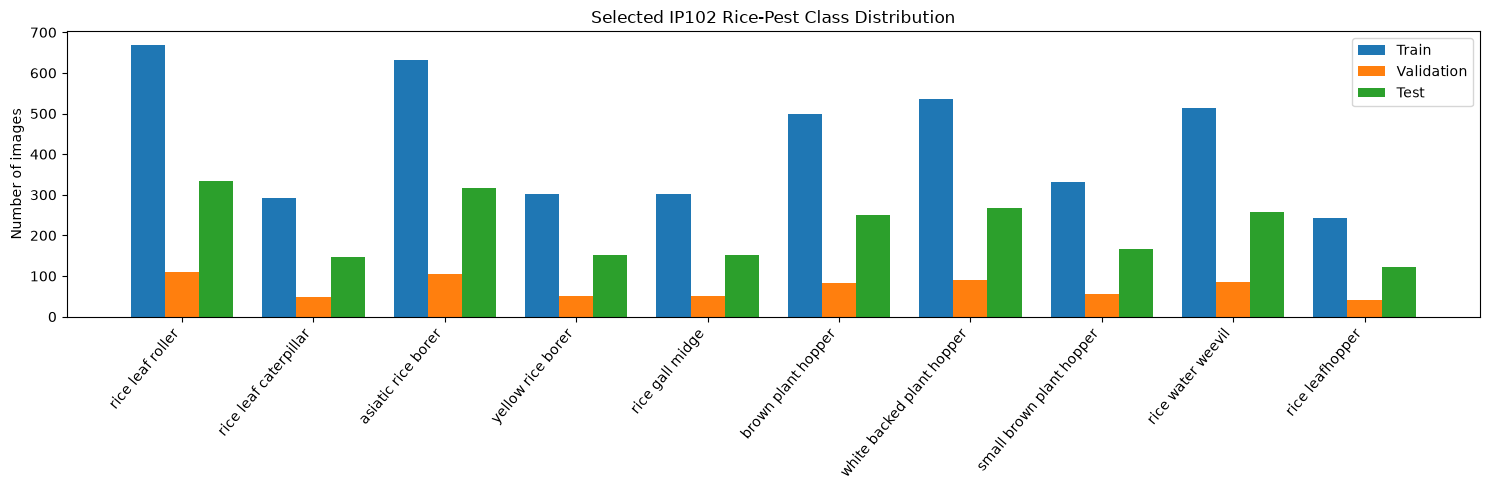

In [6]:
# Class-distribution chart for the official IP102 splits.
split_datasets = [train_dataset, val_dataset, test_dataset]
split_names = ['Train', 'Validation', 'Test']
split_counts = [
    np.bincount(dataset.labels, minlength=NUM_CLASSES)
    for dataset in split_datasets
]

x = np.arange(NUM_CLASSES)
width = 0.26
plt.figure(figsize=(15, 5))
for offset, counts, split_name in zip([-width, 0, width], split_counts, split_names):
    plt.bar(x + offset, counts, width=width, label=split_name)
plt.xticks(x, CLASS_NAMES, rotation=50, ha='right')
plt.ylabel('Number of images')
plt.title('Selected IP102 Rice-Pest Class Distribution')
plt.legend()
plt.tight_layout()
plt.show()

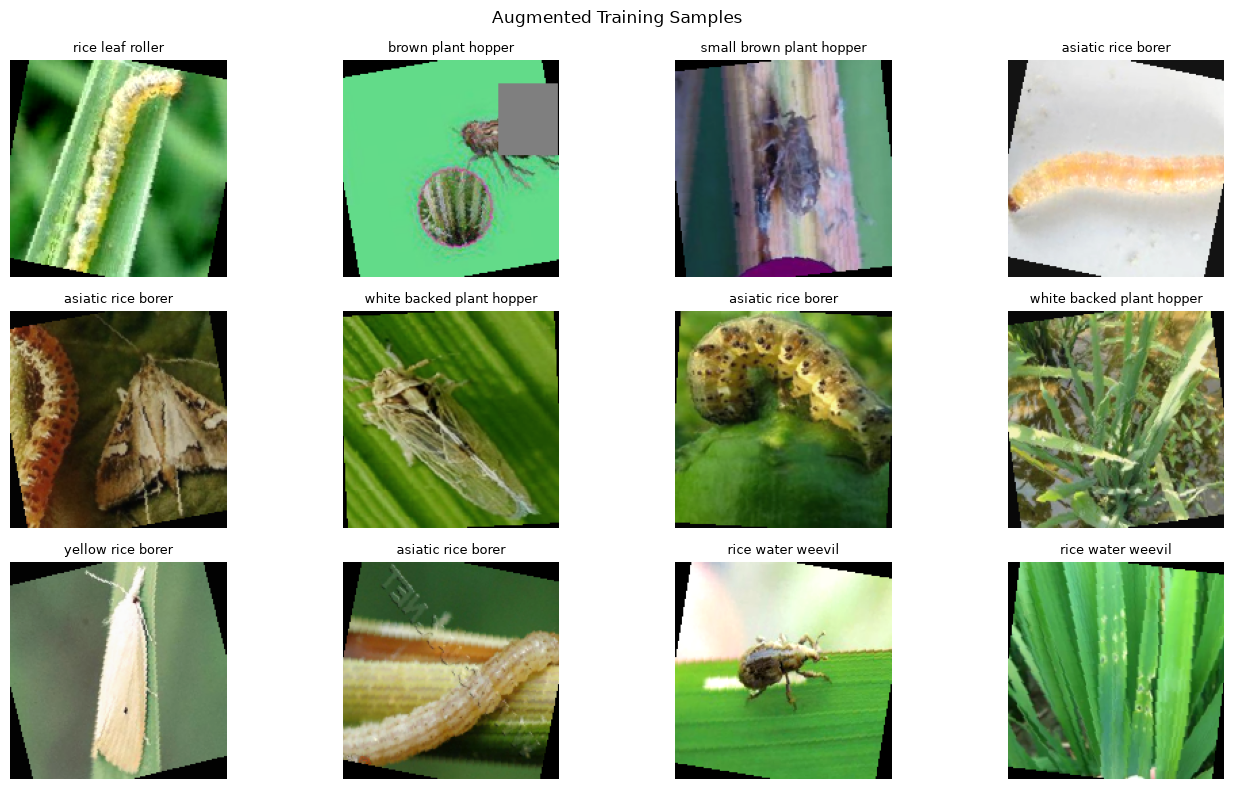

In [7]:
# Preview augmented training images.
def denormalize(image_tensor):
    mean = torch.tensor(NORMALIZE_MEAN).view(3, 1, 1)
    std = torch.tensor(NORMALIZE_STD).view(3, 1, 1)
    return (image_tensor.cpu() * std + mean).clamp(0, 1)


plt.figure(figsize=(14, 8))
for index in range(min(12, len(sample_images))):
    plt.subplot(3, 4, index + 1)
    image = denormalize(sample_images[index]).permute(1, 2, 0).numpy()
    plt.imshow(image)
    plt.title(CLASS_NAMES[sample_labels[index].item()], fontsize=9)
    plt.axis('off')
plt.suptitle('Augmented Training Samples')
plt.tight_layout()
plt.show()

## 5. Scratch-built baseline CNN

The architecture contains three convolutional blocks, global average pooling, and a small dense classifier. The imported module was written by the team from primitive layers and performs explicit Kaiming random initialization.

In [8]:
# Make the repository package importable when the notebook starts in notebooks/.
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.models import build_model

model = build_model('justin_baseline', num_classes=NUM_CLASSES, dropout=0.30).to(DEVICE)
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

with torch.inference_mode():
    shape_check = model(torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE))

print(model)
print(f'Output shape check: {tuple(shape_check.shape)}')
print(f'Trainable parameters: {trainable_parameters:,}')
assert shape_check.shape == (2, NUM_CLASSES)
assert trainable_parameters == 111_274

JustinBaselineCNN(
  (features): Sequential(
    (0): ConvBlock(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBlock(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBlock(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, p

## 6. Loss, optimizer, class weights, and scheduler

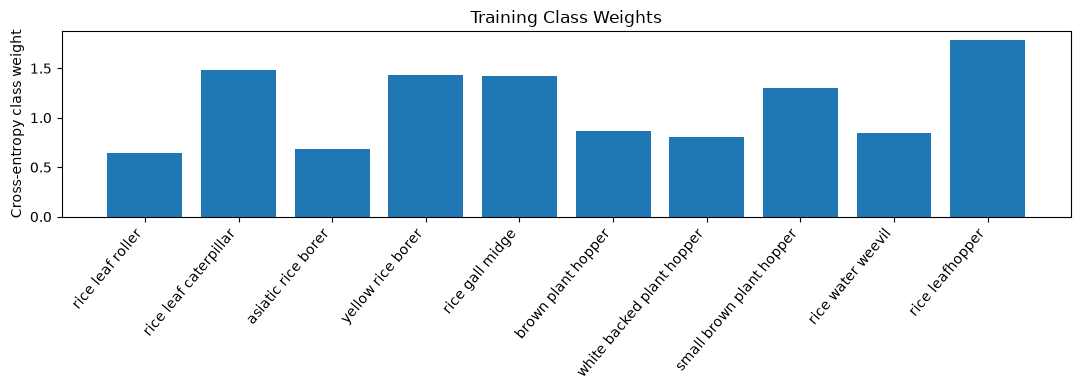

In [9]:
train_class_counts = np.bincount(train_dataset.labels, minlength=NUM_CLASSES)
class_weights = len(train_dataset) / (NUM_CLASSES * train_class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
)

plt.figure(figsize=(11, 4))
plt.bar(CLASS_NAMES, class_weights)
plt.xticks(rotation=50, ha='right')
plt.ylabel('Cross-entropy class weight')
plt.title('Training Class Weights')
plt.tight_layout()
plt.show()

## 7. Training and evaluation helpers

In [10]:
def confusion_matrix_update(confusion, labels, predictions, num_classes):
    indices = labels * num_classes + predictions
    counts = torch.bincount(indices, minlength=num_classes * num_classes)
    confusion += counts.reshape(num_classes, num_classes).cpu()


def metrics_from_confusion(confusion):
    confusion = confusion.to(torch.float64)
    true_positive = confusion.diag()
    predicted_count = confusion.sum(dim=0)
    actual_count = confusion.sum(dim=1)

    precision = true_positive / predicted_count.clamp_min(1)
    recall = true_positive / actual_count.clamp_min(1)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)
    accuracy = true_positive.sum() / confusion.sum().clamp_min(1)

    return {
        'accuracy': accuracy.item(),
        'macro_precision': precision.mean().item(),
        'macro_recall': recall.mean().item(),
        'macro_f1': f1.mean().item(),
        'per_class_precision': precision.numpy(),
        'per_class_recall': recall.numpy(),
        'per_class_f1': f1.numpy(),
    }


def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_examples = 0
    confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64)

    for images, labels, _ in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, labels)
            if is_training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_examples += batch_size
        confusion_matrix_update(confusion, labels, predictions, NUM_CLASSES)

    metrics = metrics_from_confusion(confusion)
    metrics['loss'] = total_loss / total_examples
    metrics['confusion_matrix'] = confusion
    return metrics

## 8. Train the model and print every epoch

The checkpoint with the best validation macro F1 is saved. Training stops early if macro F1 does not improve for the configured patience.

In [11]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'train_macro_f1': [],
    'val_macro_f1': [],
    'learning_rate': [],
}

best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0
best_model_path = RUN_DIR / 'best_model.pt'
training_start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.perf_counter()
    train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, criterion)

    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_accuracy'].append(train_metrics['accuracy'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['train_macro_f1'].append(train_metrics['macro_f1'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])
    history['learning_rate'].append(current_lr)

    scheduler.step(val_metrics['macro_f1'])

    improved = val_metrics['macro_f1'] > best_val_f1
    if improved:
        best_val_f1 = val_metrics['macro_f1']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'val_macro_f1': best_val_f1,
                'class_names': CLASS_NAMES,
                'selected_original_ids': SELECTED_ORIGINAL_IDS,
            },
            best_model_path,
        )
    else:
        epochs_without_improvement += 1

    elapsed = time.perf_counter() - epoch_start
    marker = ' * best' if improved else ''
    print(
        f'Epoch {epoch:02d}/{MAX_EPOCHS} | '
        f'Train loss {train_metrics["loss"]:.4f}, '
        f'acc {train_metrics["accuracy"]:.3f}, F1 {train_metrics["macro_f1"]:.3f} | '
        f'Val loss {val_metrics["loss"]:.4f}, '
        f'acc {val_metrics["accuracy"]:.3f}, F1 {val_metrics["macro_f1"]:.3f} | '
        f'LR {current_lr:.2e} | {elapsed:.1f}s{marker}'
    )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping after {epoch} epochs.')
        break

training_minutes = (time.perf_counter() - training_start) / 60
print(f'Finished training in {training_minutes:.1f} minutes.')
print(f'Best epoch: {best_epoch}; validation macro F1: {best_val_f1:.4f}')
print(f'Checkpoint: {best_model_path}')

# Save epoch history in a portable CSV file.
history_path = RUN_DIR / 'training_history.csv'
with history_path.open('w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['epoch', *history.keys()])
    for index in range(len(history['train_loss'])):
        writer.writerow([index + 1, *[history[key][index] for key in history]])
print(f'History: {history_path}')

Epoch 01/15 | Train loss 2.3349, acc 0.166, F1 0.150 | Val loss 2.2310, acc 0.190, F1 0.155 | LR 1.00e-03 | 137.3s * best
Epoch 02/15 | Train loss 2.2209, acc 0.202, F1 0.175 | Val loss 2.2238, acc 0.184, F1 0.161 | LR 1.00e-03 | 88.1s * best
Epoch 03/15 | Train loss 2.2063, acc 0.206, F1 0.180 | Val loss 2.1532, acc 0.236, F1 0.171 | LR 1.00e-03 | 89.7s * best
Epoch 04/15 | Train loss 2.1881, acc 0.219, F1 0.189 | Val loss 2.1695, acc 0.221, F1 0.155 | LR 1.00e-03 | 89.9s
Epoch 05/15 | Train loss 2.1729, acc 0.217, F1 0.187 | Val loss 2.1247, acc 0.237, F1 0.211 | LR 1.00e-03 | 90.6s * best
Epoch 06/15 | Train loss 2.1573, acc 0.231, F1 0.204 | Val loss 2.1521, acc 0.258, F1 0.222 | LR 1.00e-03 | 76.3s * best
Epoch 07/15 | Train loss 2.1431, acc 0.236, F1 0.206 | Val loss 2.0813, acc 0.273, F1 0.224 | LR 1.00e-03 | 80.0s * best
Epoch 08/15 | Train loss 2.1303, acc 0.248, F1 0.221 | Val loss 2.0891, acc 0.262, F1 0.214 | LR 1.00e-03 | 76.1s
Epoch 09/15 | Train loss 2.1156, acc 0.252, F

## 9. Plot loss, accuracy, macro F1, and learning rate

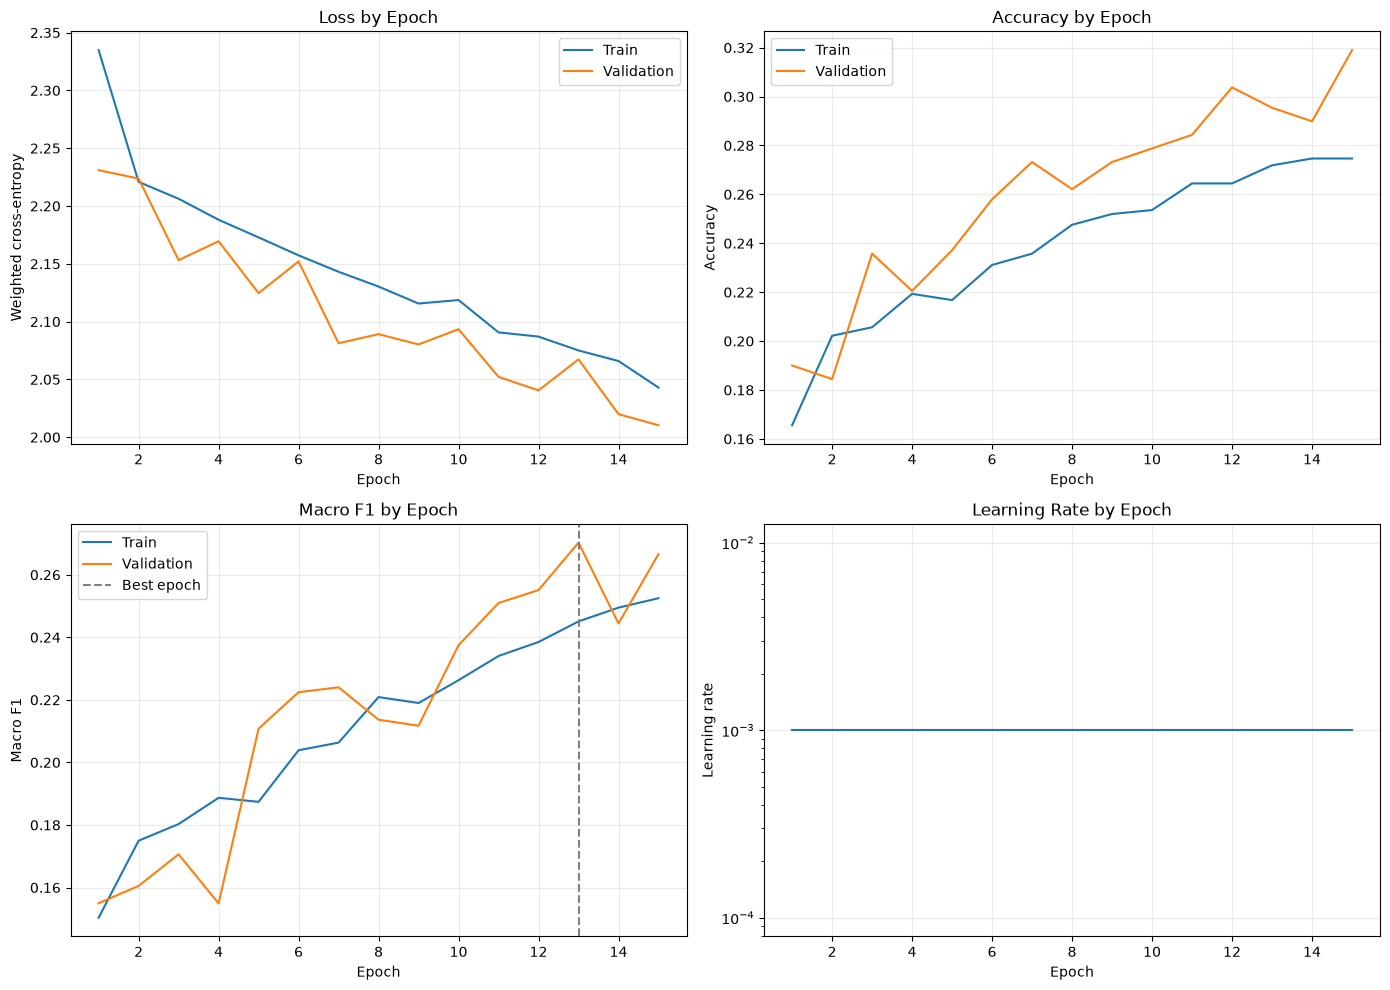

Saved chart: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI\runs\justin_baseline_notebook\training_curves.png


In [12]:
epochs = np.arange(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(epochs, history['train_loss'], label='Train')
axes[0, 0].plot(epochs, history['val_loss'], label='Validation')
axes[0, 0].set_title('Loss by Epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Weighted cross-entropy')
axes[0, 0].legend()

axes[0, 1].plot(epochs, history['train_accuracy'], label='Train')
axes[0, 1].plot(epochs, history['val_accuracy'], label='Validation')
axes[0, 1].set_title('Accuracy by Epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

axes[1, 0].plot(epochs, history['train_macro_f1'], label='Train')
axes[1, 0].plot(epochs, history['val_macro_f1'], label='Validation')
axes[1, 0].axvline(best_epoch, color='gray', linestyle='--', label='Best epoch')
axes[1, 0].set_title('Macro F1 by Epoch')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Macro F1')
axes[1, 0].legend()

axes[1, 1].plot(epochs, history['learning_rate'])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Learning Rate by Epoch')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning rate')

for axis in axes.flat:
    axis.grid(alpha=0.25)

plt.tight_layout()
curve_path = RUN_DIR / 'training_curves.png'
plt.savefig(curve_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved chart: {curve_path}')

## 10. Evaluate the best checkpoint on the untouched test set

In [ ]:
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

test_metrics = run_epoch(model, test_loader, criterion)
print(f'Test loss:            {test_metrics["loss"]:.4f}')
print(f'Test accuracy:        {test_metrics["accuracy"]:.4f}')
print(f'Test macro precision: {test_metrics["macro_precision"]:.4f}')
print(f'Test macro recall:    {test_metrics["macro_recall"]:.4f}')
print(f'Test macro F1:        {test_metrics["macro_f1"]:.4f}')


# Precision: Higher is better, measure of correctness
# Recall: Higher is better, measure of completeness
# F1: Higher is better, measure of balance between precision and recall
print('\nPer-class results:')
for index, name in enumerate(CLASS_NAMES):
    print(
        f'{index:2d} {name:30s} | '
        f'P {test_metrics["per_class_precision"][index]:.3f} | '
        f'R {test_metrics["per_class_recall"][index]:.3f} | '
        f'F1 {test_metrics["per_class_f1"][index]:.3f}'
    )

Test loss:            2.0825
Test accuracy:        0.2849
Test macro precision: 0.2783
Test macro recall:    0.2860
Test macro F1:        0.2709

Per-class results:
 0 rice leaf roller               | P 0.485 | R 0.337 | F1 0.398
 1 rice leaf caterpillar          | P 0.202 | R 0.122 | F1 0.153
 2 asiatic rice borer             | P 0.338 | R 0.247 | F1 0.285
 3 yellow rice borer              | P 0.249 | R 0.382 | F1 0.301
 4 rice gall midge                | P 0.270 | R 0.539 | F1 0.360
 5 brown plant hopper             | P 0.257 | R 0.263 | F1 0.260
 6 white backed plant hopper      | P 0.235 | R 0.332 | F1 0.276
 7 small brown plant hopper       | P 0.198 | R 0.145 | F1 0.167
 8 rice water weevil              | P 0.314 | R 0.214 | F1 0.255
 9 rice leafhopper                | P 0.234 | R 0.279 | F1 0.255


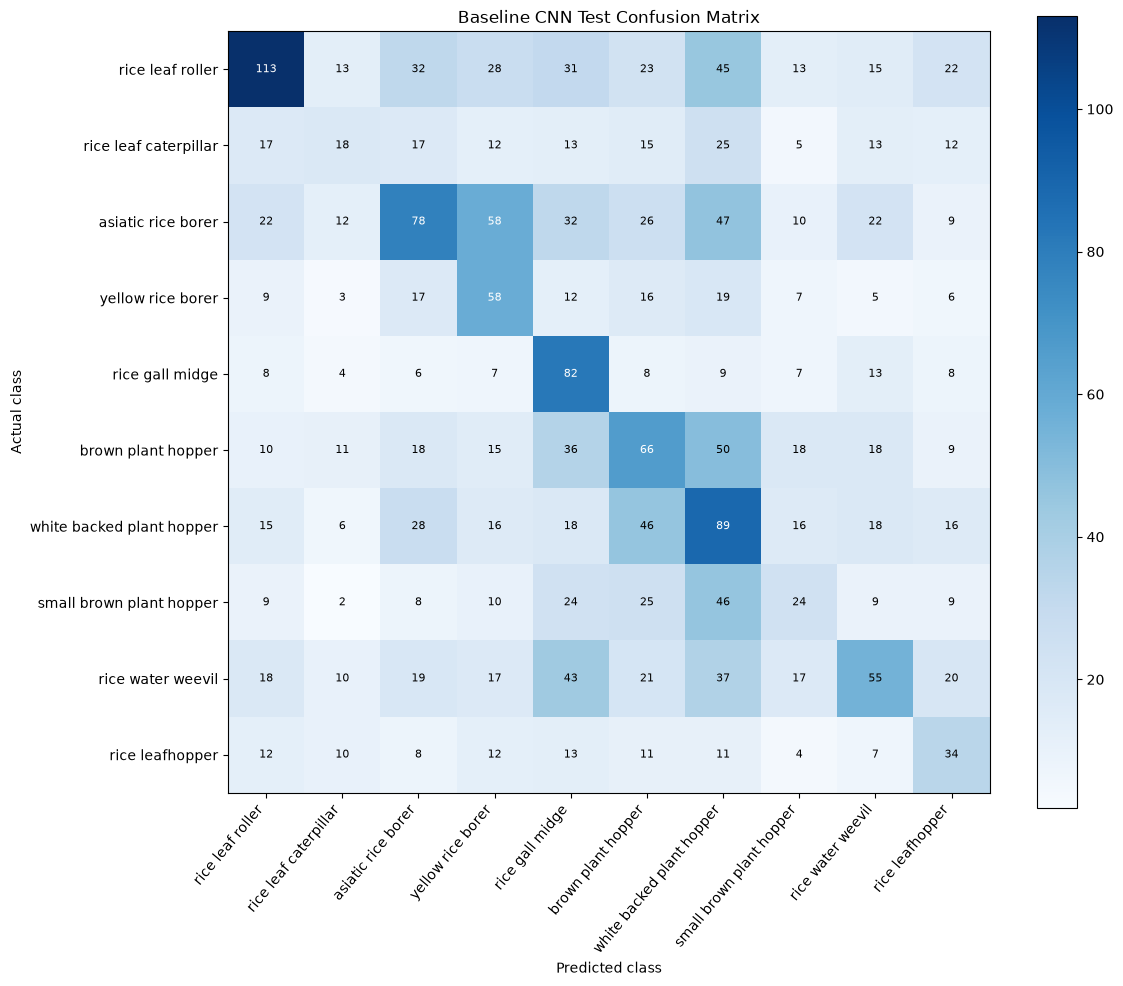

Saved chart: C:\Users\justi\Programming Projs\FPT-MLCV\FarmPestManagementAI\runs\justin_baseline_notebook\confusion_matrix.png


In [15]:
# Confusion matrix: rows are actual classes and columns are predictions.
confusion = test_metrics['confusion_matrix'].numpy()
fig, axis = plt.subplots(figsize=(12, 10))
image = axis.imshow(confusion, interpolation='nearest', cmap='Blues')
fig.colorbar(image, ax=axis)
axis.set(
    xticks=np.arange(NUM_CLASSES),
    yticks=np.arange(NUM_CLASSES),
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    xlabel='Predicted class',
    ylabel='Actual class',
    title='Baseline CNN Test Confusion Matrix',
)
plt.setp(axis.get_xticklabels(), rotation=50, ha='right')

threshold = confusion.max() / 2
for row in range(NUM_CLASSES):
    for column in range(NUM_CLASSES):
        axis.text(
            column,
            row,
            int(confusion[row, column]),
            ha='center',
            va='center',
            color='white' if confusion[row, column] > threshold else 'black',
            fontsize=8,
        )

plt.tight_layout()
confusion_path = RUN_DIR / 'confusion_matrix.png'
plt.savefig(confusion_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved chart: {confusion_path}')

## 11. Inspect sample test predictions

Correct predictions are shown in green and errors in red. Each title includes the model confidence.

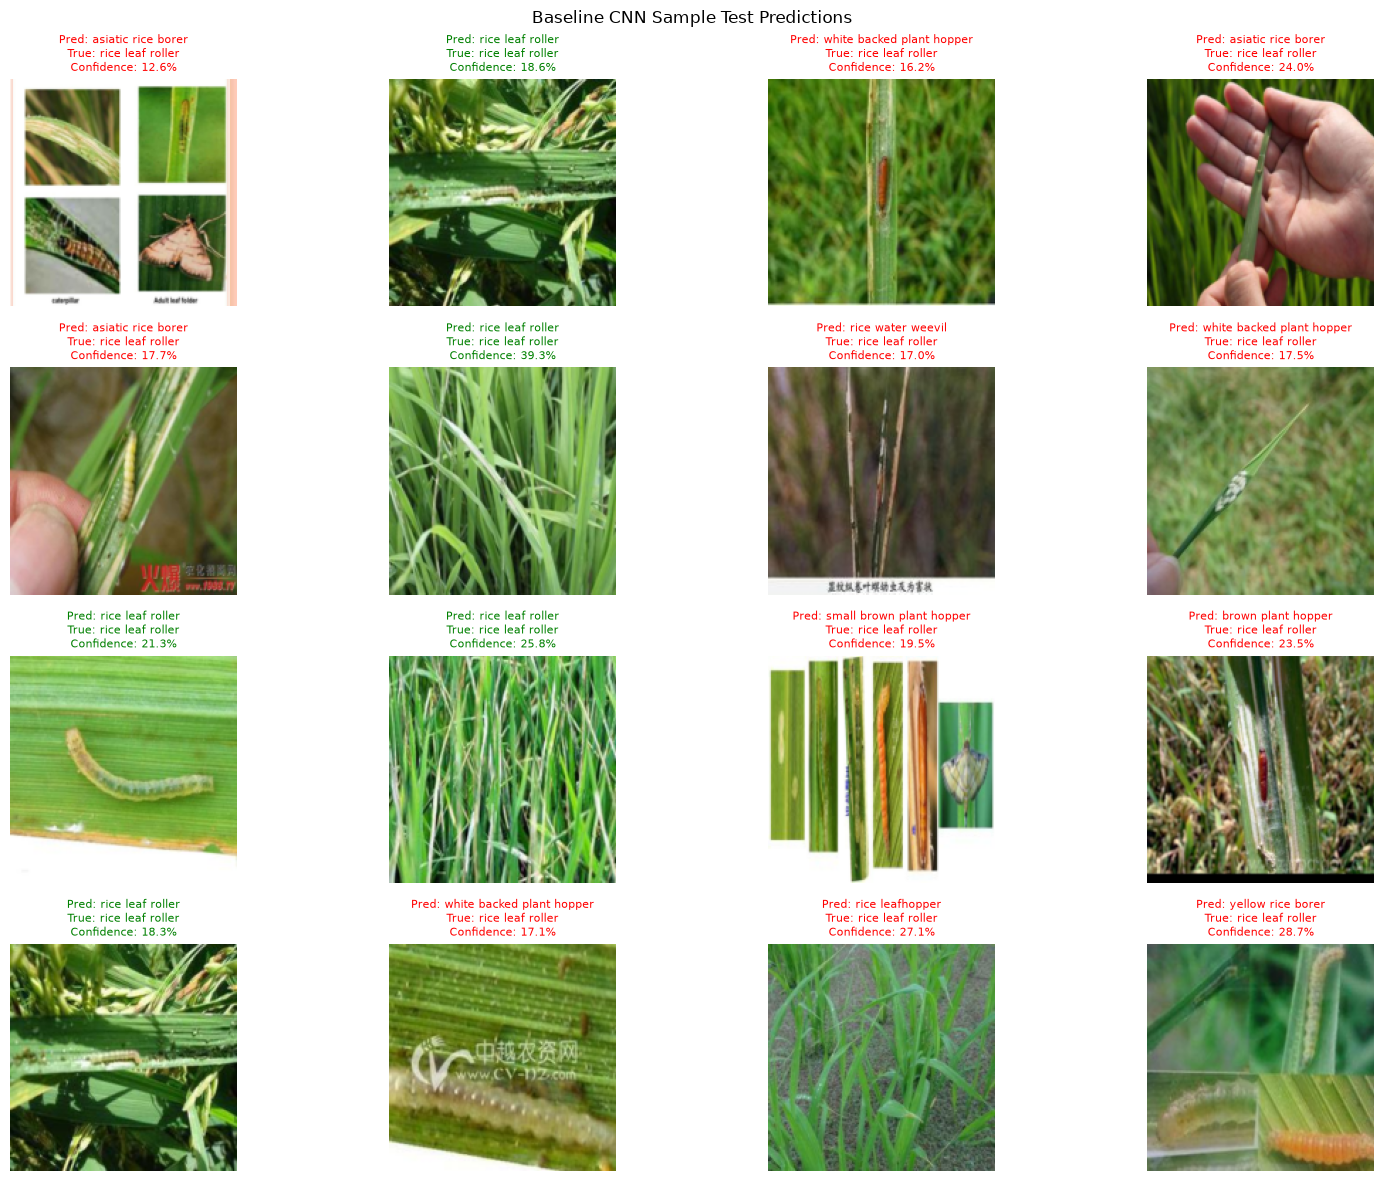

In [17]:
test_images, test_labels, test_filenames = next(iter(test_loader))
with torch.inference_mode():
    probabilities = torch.softmax(model(test_images.to(DEVICE)), dim=1).cpu()
predictions = probabilities.argmax(dim=1)
confidences = probabilities.max(dim=1).values

plt.figure(figsize=(16, 12))
for index in range(min(16, len(test_images))):
    actual = test_labels[index].item()
    predicted = predictions[index].item()
    correct = actual == predicted

    plt.subplot(4, 4, index + 1)
    image = denormalize(test_images[index]).permute(1, 2, 0).numpy()
    plt.imshow(image)
    plt.title(
        f'Pred: {CLASS_NAMES[predicted]}\n'
        f'True: {CLASS_NAMES[actual]}\n'
        f'Confidence: {confidences[index]:.1%}',
        color='green' if correct else 'red',
        fontsize=8,
    )
    plt.axis('off')
plt.suptitle('Baseline CNN Sample Test Predictions')
plt.tight_layout()
plt.show()

## Next experiments

After this baseline runs successfully, keep the data pipeline and initial training configuration fixed while the five team members compare the shallow baseline, deep sequential, custom residual, multi-scale, and lightweight scratch-built CNNs. Use validation macro F1 to select checkpoints and report the untouched test set only after model decisions are complete.